# PLS Gradient Progression — LV scores vs age, per parcel

A third view on the frozen AHBA PLS basis (after `eval_pls_gradients_onbrain`): for a **single parcel**,
how do the molecular LV scores move **with age**? Each subject's region×gene slice is projected onto the
frozen AHBA basis (LV1–3), the parcel's scores are pulled, subjects are grouped by GTEx decade-midpoint age,
and we plot mean ± SEM per LV across age.

- **GTEx ROI** (a GTEx–AHBA matched parcel): two plots — `loro_truth` (harmonized ground truth) and
  `loro_fused` (dense reconstruction).
- **Extrapolated ROI** (any S156 parcel GTEx never sampled): `loro_fused` only.
- Parcels are addressed by **S156 `parcel_idx`** (int) or **native parcel name** (str).

Config is read FROM the cache so views/basis can't drift from the model fit. Logic:
`src/eval_utils/eval_pls_gradient_progression.py` (`+ eval_pls_gradients`, `src/latent/pls.py`).

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from src.eval_utils.eval_style import set_academic_style
from src.eval_utils.eda_core import prepare_pre_post_harmonization_cached
from src.eval_utils.eval_samples import (
    MatchingContext, build_prediction_tensor_view, build_combat_tensor_view)
from src.eval_utils import eval_pls_gradients as pg
from src.eval_utils import eval_pls_gradient_progression as pgp

set_academic_style()

## 1 · Which cache (config comes FROM it)
*Toggle:* only the cache selectors. Matching/harmonization hparams are pulled from the cache's stored config.

In [2]:
CACHE_ROOT = 'out/loro_subject_cache_cv_shrink'
MODEL_NAME = 'plam'         # 'dlam' | 'plam' | 'naive'
GENE_SCOPE = 'allgenes'     # 'allgenes' | 'hvg'

cfg, CFG = pg.build_cfg_from_cache(CACHE_ROOT, MODEL_NAME, GENE_SCOPE)
N_COMP = int(CFG.get('n_comp_target', 3))
print('cache config:', {k: CFG.get(k) for k in
      ['matching_policy', 'matching_policy_hemi_mode', 'gtex_rep_mode', 'gtex_hemi_mode',
       'collapse_cerebellum', 'combat_use_covariates', 'min_observed_parcels', 'n_comp_target']})

cache config: {'matching_policy': 'centroids_and_volumes', 'matching_policy_hemi_mode': 'force_left', 'gtex_rep_mode': 'centroid', 'gtex_hemi_mode': 'mirror_left', 'collapse_cerebellum': False, 'combat_use_covariates': True, 'min_observed_parcels': 5, 'n_comp_target': 3}


## 2 · PREPOST + frozen AHBA basis
Freeze the AHBA latent axes exactly as DLAM does (`build_region_matrix` + `[y, z, |x|]`).

In [3]:
REGION_ORDERING = 'target_parcel'   # parcel_idx frame == DLAM reference
BASIS_CACHE     = f'out/pls_basis/ahba_basis__{GENE_SCOPE}.pkl'   # None to always refit

prepost = prepare_pre_post_harmonization_cached(cfg)
ctx = MatchingContext.from_cfg(cfg, prepost)
tier_b = dict(cfg=cfg, matching_context=ctx, region_ordering=REGION_ORDERING,
              gene_panel=None, n_regions=None, n_genes=None, random_seed=42)
TARGET_META = prepost['target_meta']

basis, T_ahba, REGIONS = pg.fit_ahba_basis(prepost, n_comp=N_COMP, cache_path=BASIS_CACHE)
print(f'AHBA basis: {int(basis["n_comp"])} LVs over {len(REGIONS)} parcels x {len(list(prepost["genes"]))} genes')

[prepost_cache] hit  notebooks/cache/prepost/b8c1d9d0503e5133.pkl  (8961.2 MB)


/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:356: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


AHBA basis: 3 LVs over 150 parcels x 11704 genes


## 3 · Project ALL subjects onto the basis (once per stage)
Three stages, projected to `(subjects, regions, LV)` on the same frozen AHBA axes:
- **`raw`** — non-harmonized GTEx (`build_combat_tensor_view`, `raw_matched`); sparse (observed parcels only).
- **`loro_truth`** — harmonized held-out ground truth; sparse (the GTEx-matched parcels).
- **`loro_fused`** — dense reconstruction (every S156 parcel).

Ages are GTEx decade midpoints. *Note:* `raw` is projected through a basis standardized on **harmonized**
AHBA, so its absolute LV offset reflects the un-corrected dataset shift — read the age *trend*, not the
absolute level, against the harmonized stages.

In [4]:
STAGES = ('raw', 'loro_truth', 'loro_fused')


def _build_view(stage):
    if stage == 'raw':
        return build_combat_tensor_view(prepost, dataset='GTEx', stage='raw_matched', cfg=cfg,
                                        matching_context=ctx, region_ordering=REGION_ORDERING)
    return build_prediction_tensor_view(CACHE_ROOT, MODEL_NAME, dataset='GTEx', stage=stage,
                                        subjects=None, n_subjects=None, **tier_b)


T_BY_STAGE, AGES_BY_STAGE = {}, {}
for stage in STAGES:
    view = _build_view(stage)
    assert list(view.regions) == list(REGIONS), f'{stage} regions must match the AHBA basis frame'
    T_BY_STAGE[stage] = pgp.project_all_subjects(basis, view)
    AGES_BY_STAGE[stage] = pgp.subject_ages(prepost, list(view.subjects))
    aged = int(np.isfinite(AGES_BY_STAGE[stage]).sum())
    print(f'{stage:11s}: T_all {T_BY_STAGE[stage].shape}  | {aged}/{len(view.subjects)} subjects with age')

# GTEx-matched parcels (held-out truth exists); everything else is extrapolation-only.
MATCHED_MASK = np.isfinite(T_BY_STAGE['loro_truth'][:, :, 0]).any(axis=0)
print('age bins:', np.unique(AGES_BY_STAGE['loro_truth'][np.isfinite(AGES_BY_STAGE['loro_truth'])]).astype(int).tolist())
print(f'{int(MATCHED_MASK.sum())} GTEx-matched parcels, {int((~MATCHED_MASK).sum())} extrapolated')

raw        : T_all (318, 150, 3)  | 318/318 subjects with age
loro_truth : T_all (318, 150, 3)  | 318/318 subjects with age
loro_fused : T_all (318, 150, 3)  | 318/318 subjects with age
age bins: [24, 34, 44, 54, 64, 74]
12 GTEx-matched parcels, 138 extrapolated


## 4 · All GTEx-matched parcels — raw → harmonized truth → reconstruction grids
The 12 GTEx–AHBA matched parcels as 3×4 grids of LV-gradient progressions, one grid per provenance stage:
**raw GTEx** (non-harmonized) → **harmonized ground truth** (`loro_truth`) → **reconstruction**
(`loro_fused`). Each cell is one parcel; each line is an LV (cividis/plasma/viridis) with a ±1 SEM band.
Reading across the three grids shows where the age structure originates — in the data, in harmonization,
or in reconstruction.

12 matched parcels: ['Cerebellar_Region4', 'Cerebellar_Region7', 'LH-Ca', 'LH-HTH', 'LH-NAC', 'LH-Pu', 'LH-SNr', 'LH_Amygdala', 'LH_Default_PFC_4', 'LH_Hippocampus', 'LH_SalVentAttn_Med_1', 'LH_SalVentAttn_PFCl_1']
saved out/brain_renders/pls_progression_grid__gtex_raw.png


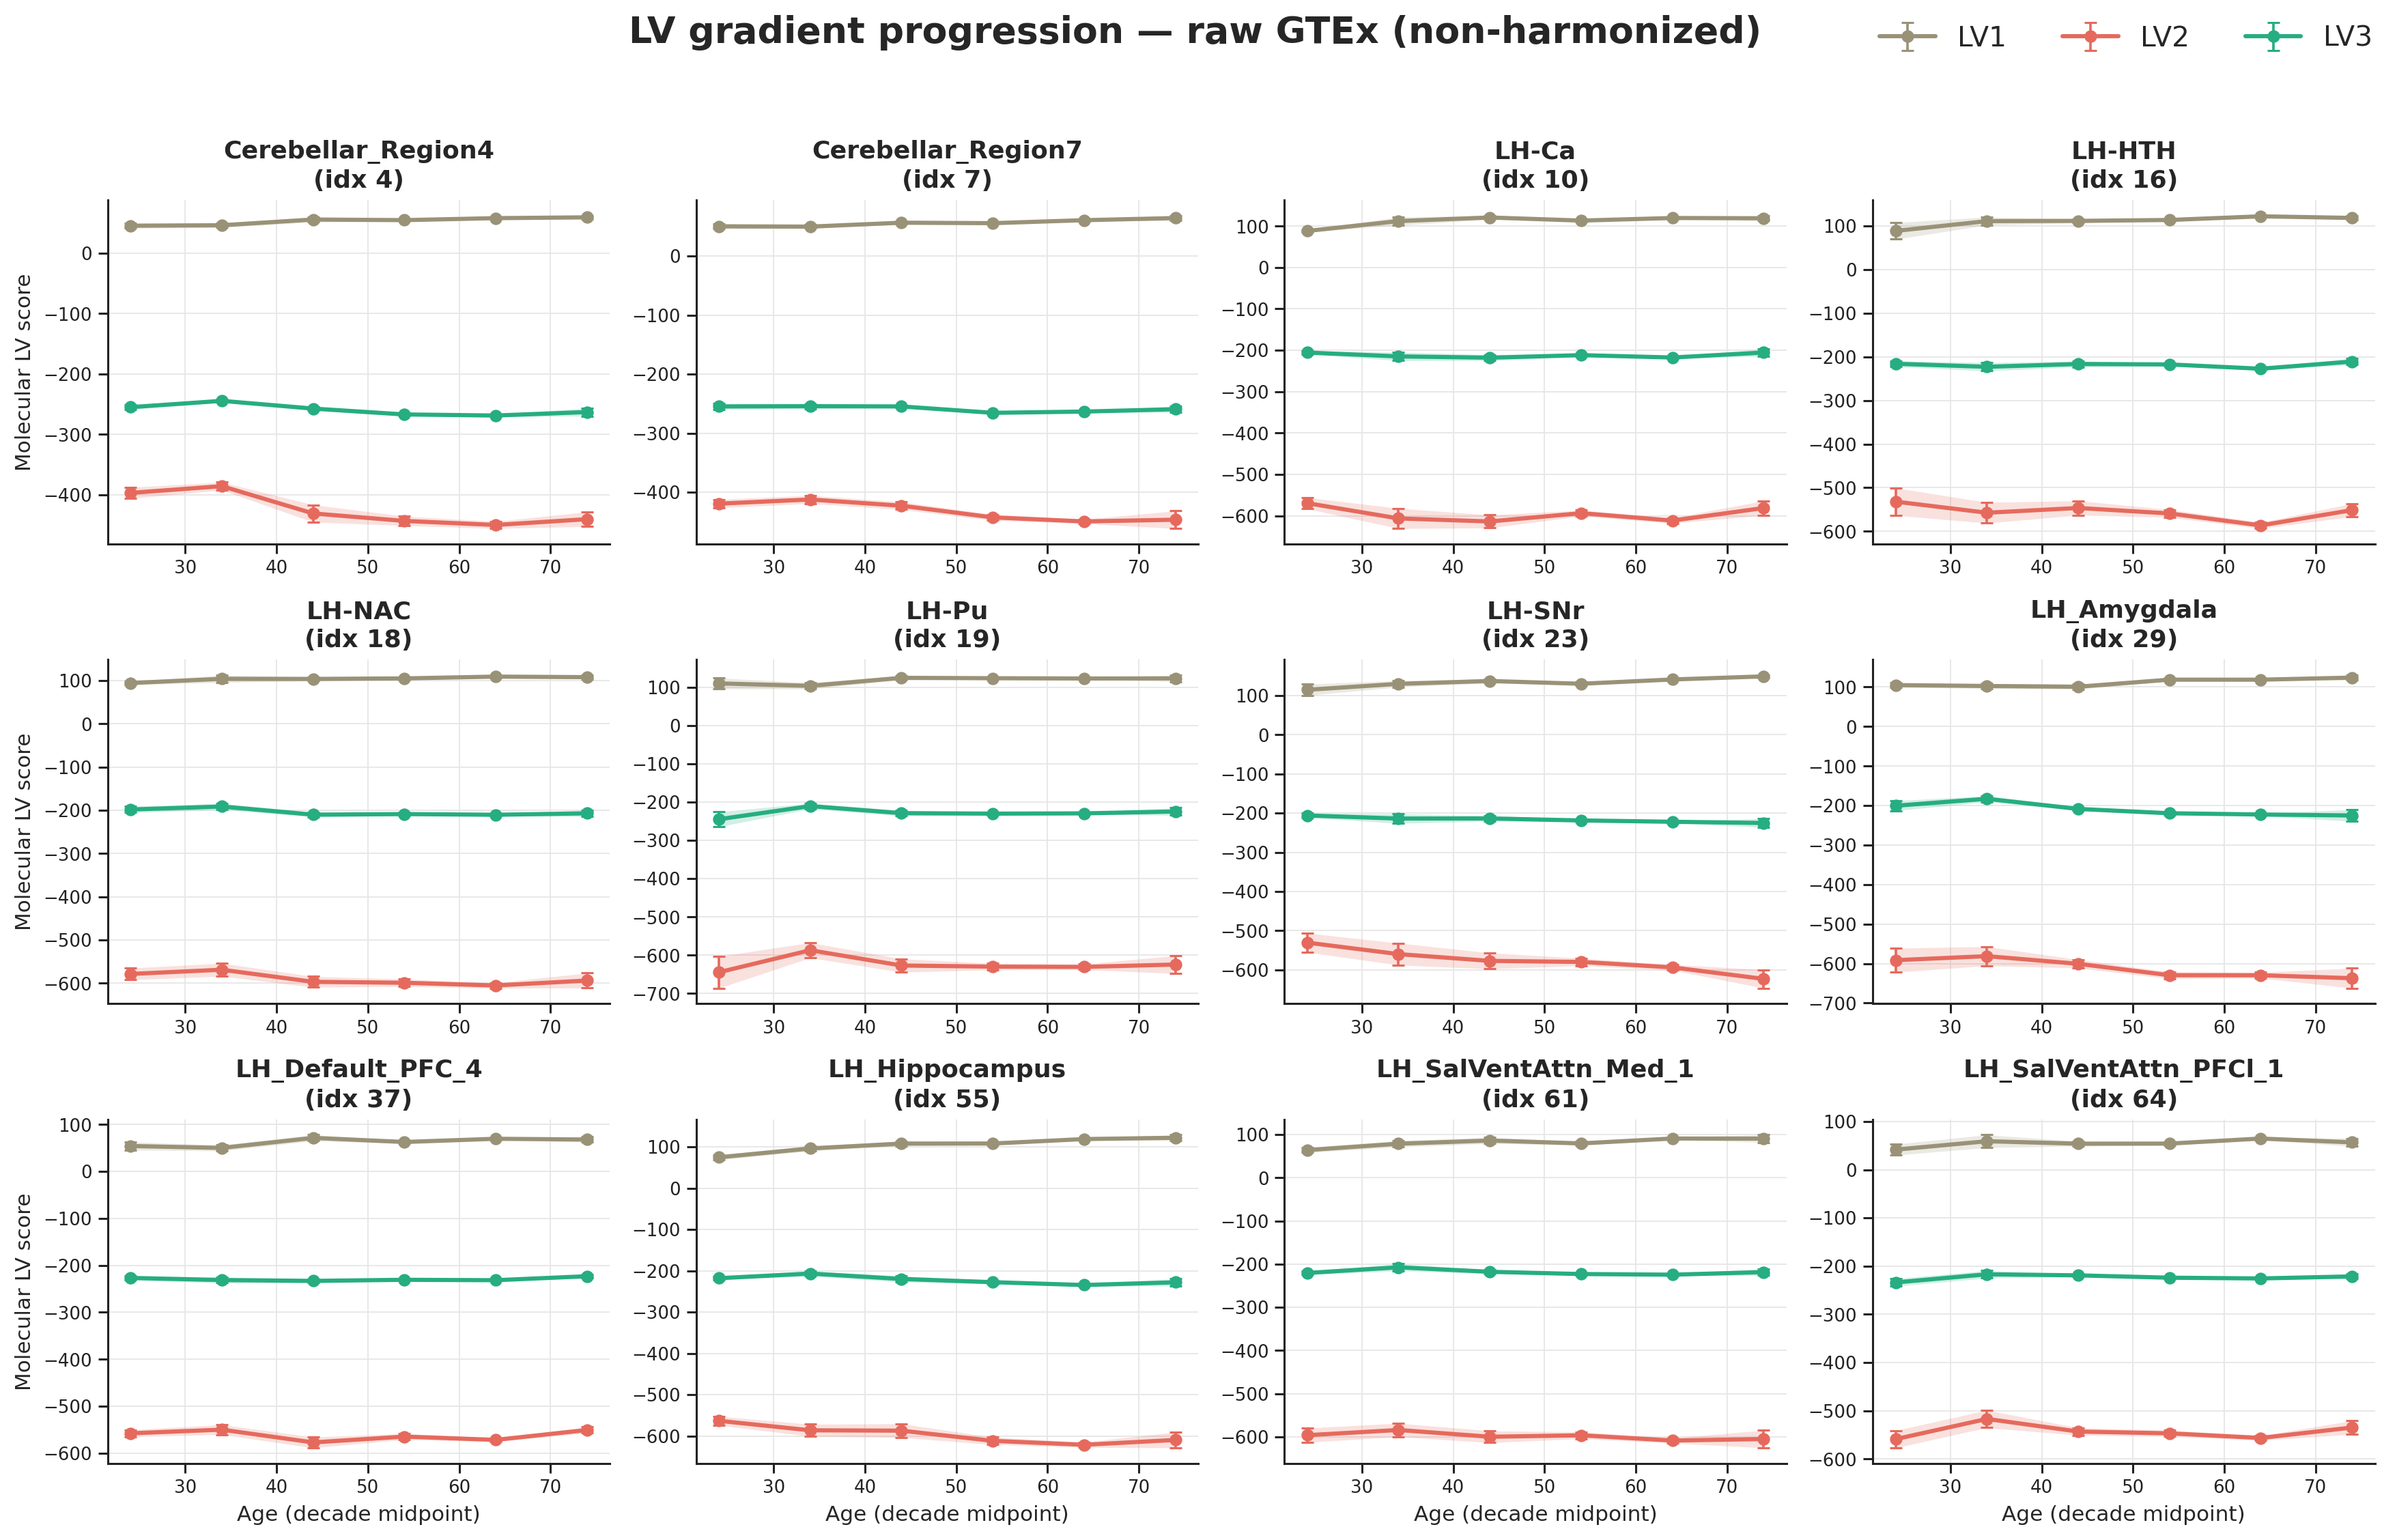

saved out/brain_renders/pls_progression_grid__gtex_truth.png


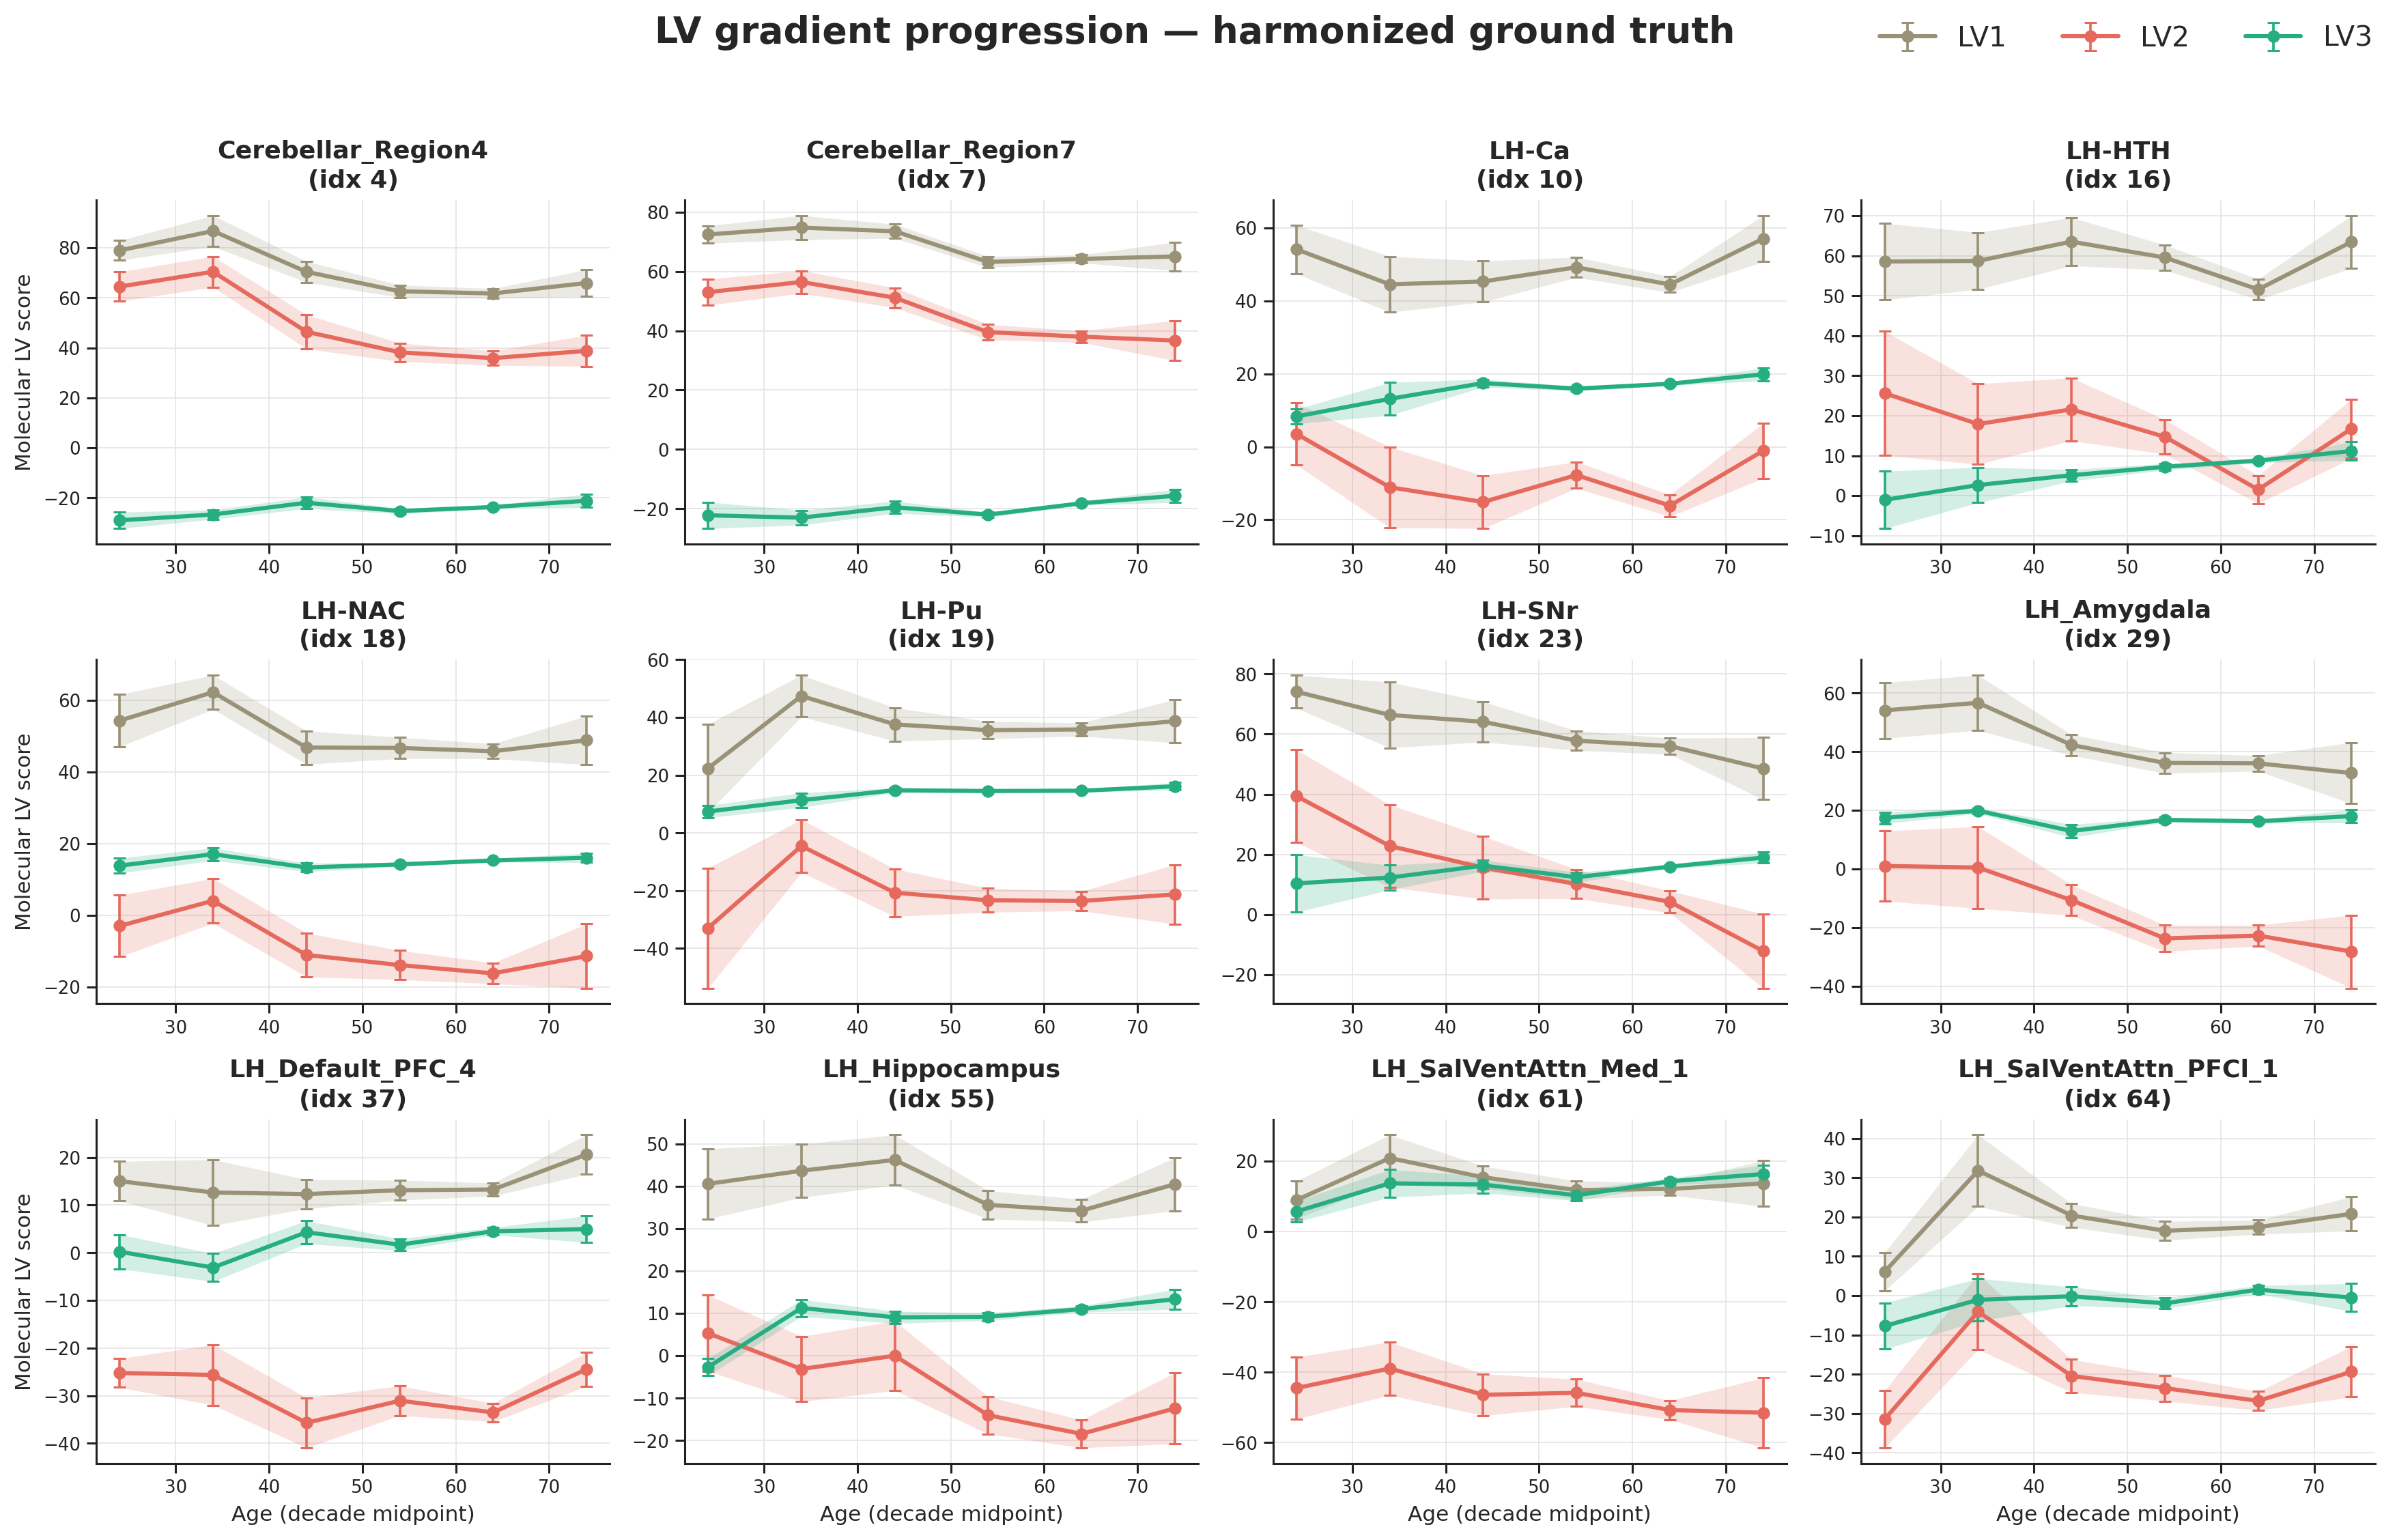

saved out/brain_renders/pls_progression_grid__gtex_recon.png


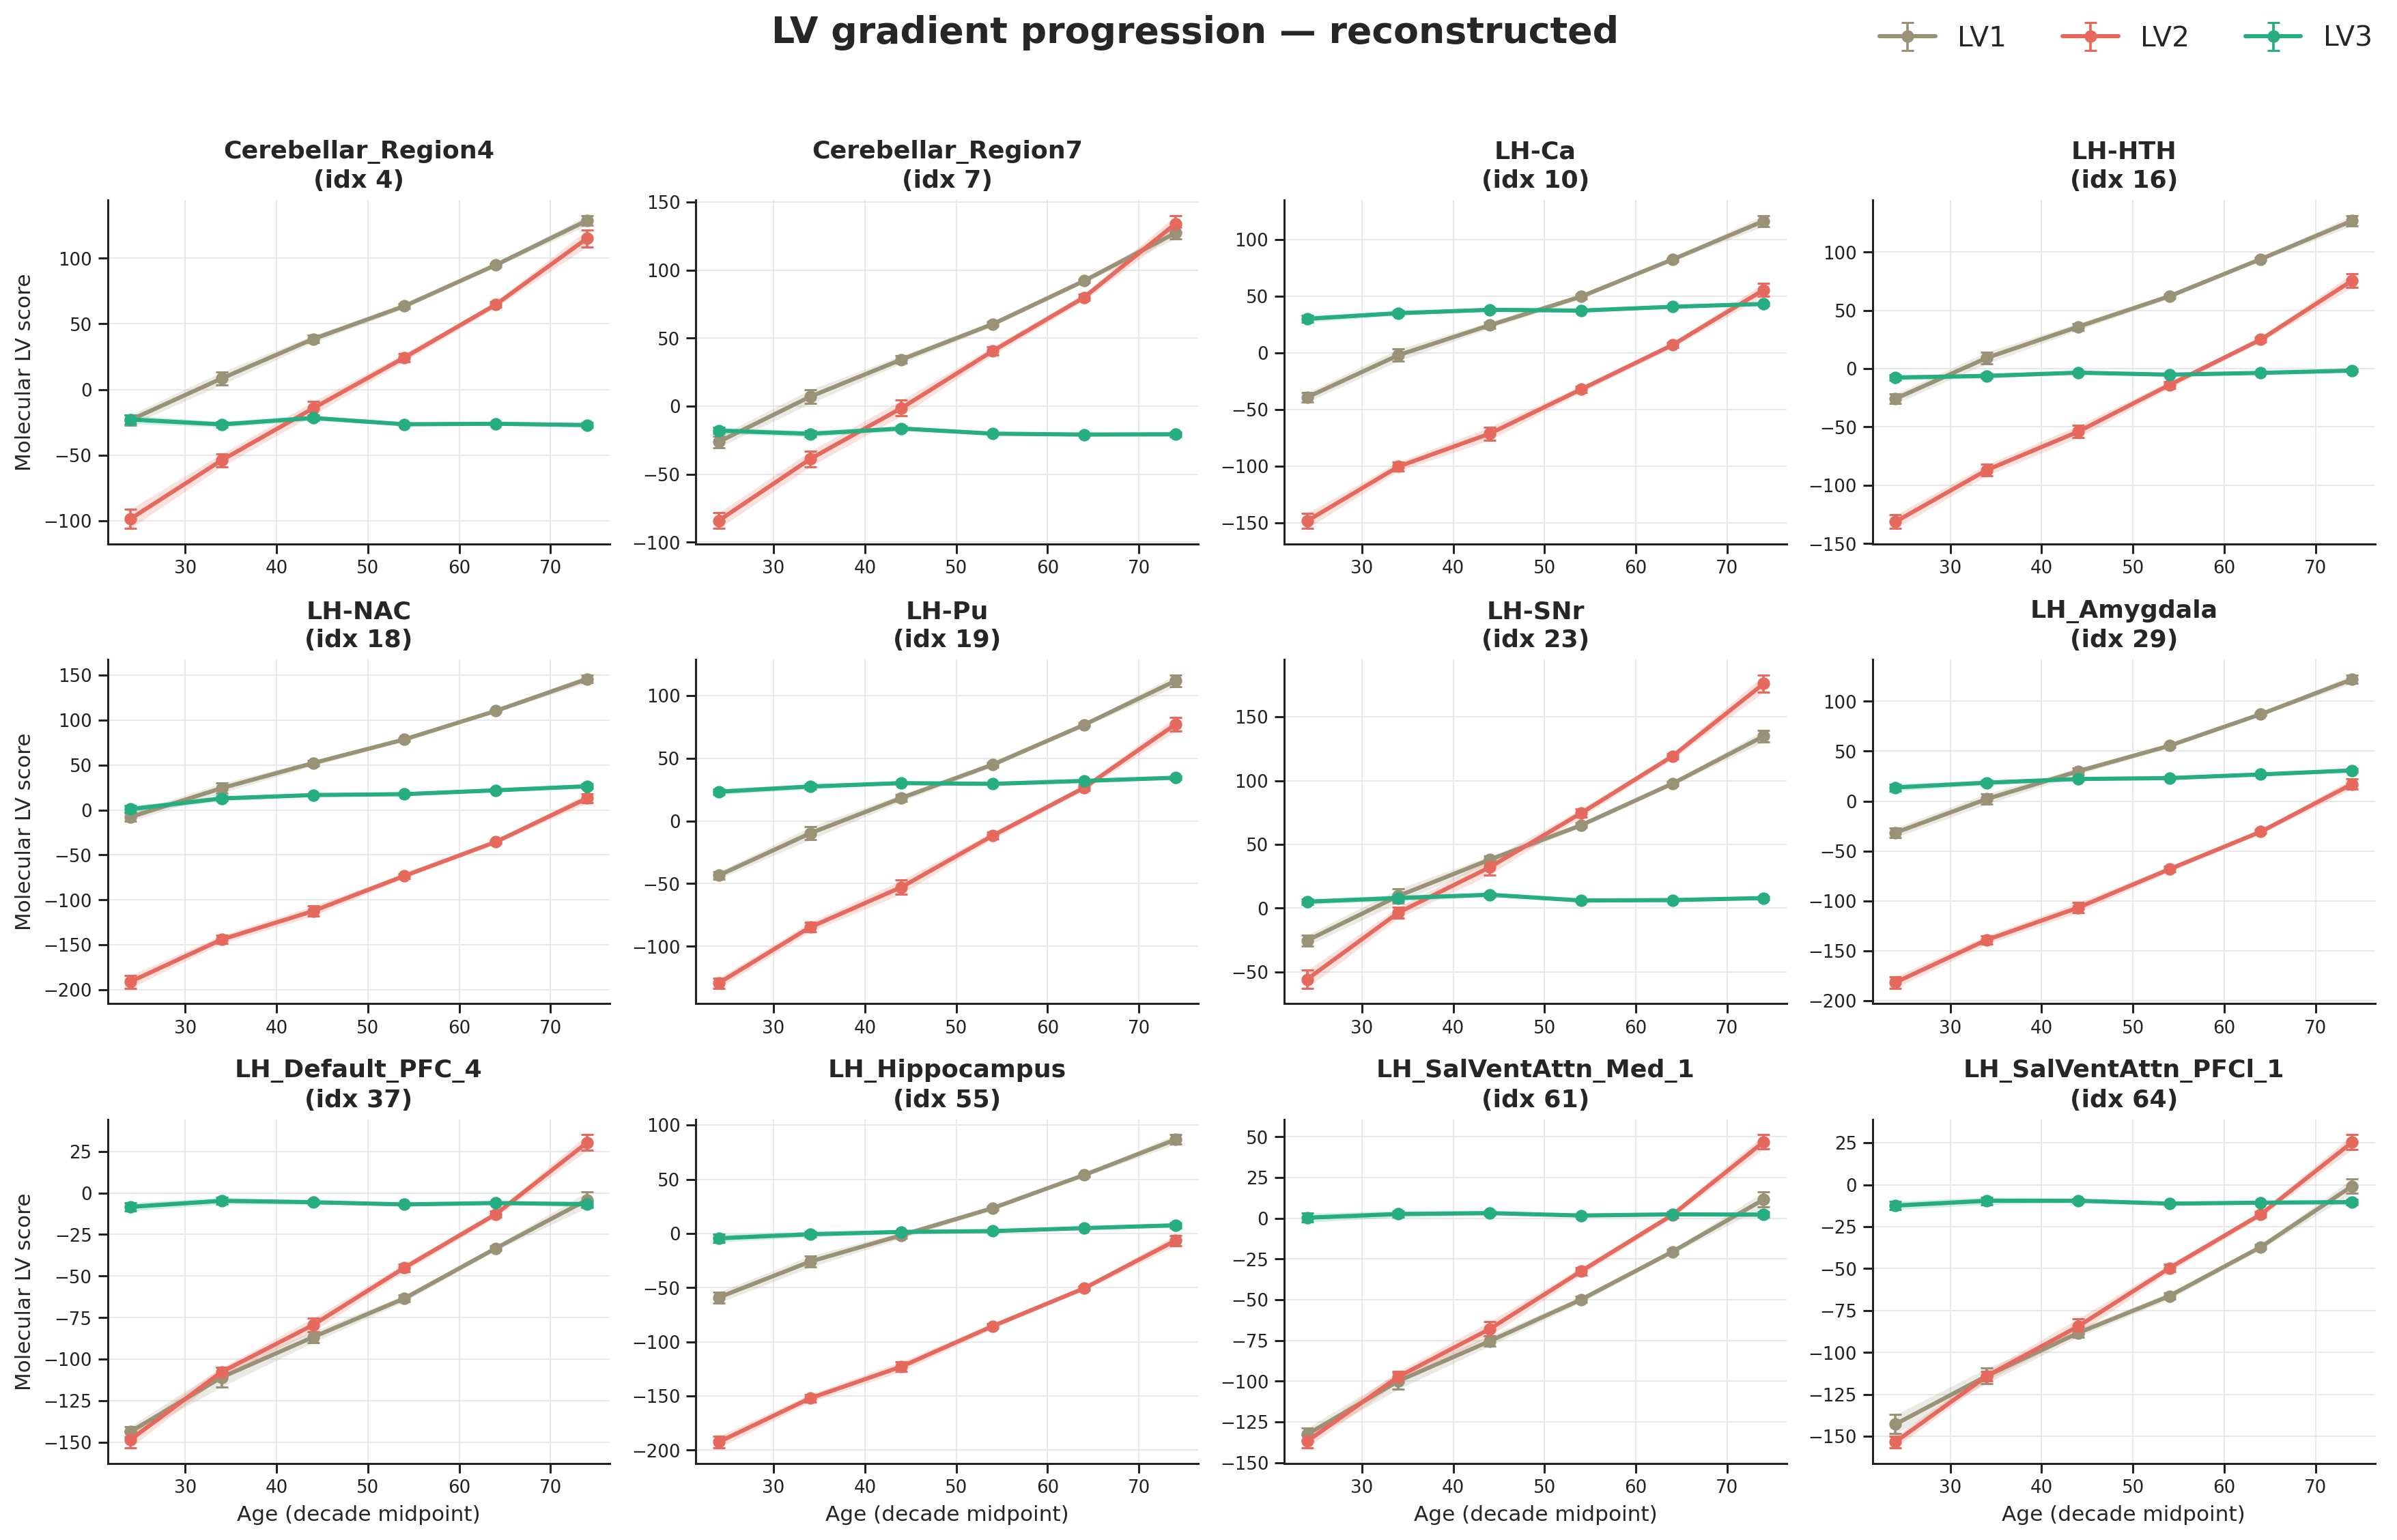

In [5]:
SHOW_SCATTER = False                # overlay individual subjects behind the lines
FONT_SCALE   = 0.85                 # grid cells are small; scale text down
EXPORT_DIR   = 'out/brain_renders'  # None to skip saving

MATCHED_PARCELS = [REGIONS[i] for i in np.where(MATCHED_MASK)[0]]
print(f'{len(MATCHED_PARCELS)} matched parcels:', MATCHED_PARCELS)

# One 3x4 grid per stage: raw GTEx -> harmonized truth -> reconstruction.
GRID_STAGES = (('raw', 'raw GTEx (non-harmonized)', 'gtex_raw'),
               ('loro_truth', 'harmonized ground truth', 'gtex_truth'),
               ('loro_fused', 'reconstructed', 'gtex_recon'))
for stage, lab, tag in GRID_STAGES:
    pgp.render_progression_grid(T_BY_STAGE[stage], AGES_BY_STAGE[stage], REGIONS, TARGET_META, MATCHED_PARCELS,
                                stage_label=lab, n_rows=3, n_cols=4, n_lv=N_COMP,
                                show_scatter=SHOW_SCATTER, font_scale=FONT_SCALE,
                                export_dir=EXPORT_DIR, export_tag=tag)

## 5 · Per-parcel selector — hone in on one parcel (matched or extrapolated)
*Toggle:* `PARCEL` (S156 `parcel_idx` int **or** native parcel name str). The lister below shows every
addressable parcel with a `has_truth` flag. A GTEx-matched parcel (`has_truth=True`) gives the full
**raw → harmonized truth → reconstruction** triplet; an extrapolation-only parcel gives the
**reconstruction** alone (GTEx never sampled it, so no raw or held-out truth exists there).

In [6]:
# Every addressable parcel with a has_truth flag (True = GTEx-matched, False = extrapolation-only).
_truth_by_name = {REGIONS[i]: bool(np.isfinite(T_BY_STAGE['loro_truth'][:, i, 0]).any())
                  for i in range(len(REGIONS))}
PARCELS = TARGET_META[['parcel_idx', 'tissue_or_parcel']].copy()
PARCELS['has_truth'] = PARCELS['tissue_or_parcel'].astype(str).map(_truth_by_name).fillna(False)
PARCELS = PARCELS.sort_values('parcel_idx').reset_index(drop=True)
print(f"{int(PARCELS['has_truth'].sum())} matched (has_truth) / {int((~PARCELS['has_truth']).sum())} extrapolated")
PARCELS

12 matched (has_truth) / 138 extrapolated


,parcel_idx,tissue_or_parcel,has_truth
0,0,Cerebellar_Region1,False
1,1,Cerebellar_Region10,False
2,2,Cerebellar_Region2,False
3,3,Cerebellar_Region3,False
4,4,Cerebellar_Region4,True
...,...,...,...
145,145,RH_Vis_4,False
146,146,RH_Vis_5,False
147,147,RH_Vis_6,False
148,148,RH_Vis_7,False


LH_Vis_4 (idx 75) is extrapolated — GTEx never sampled it; reconstruction only.
saved out/brain_renders/pls_progression__LH_Vis_4__loro_fused.png


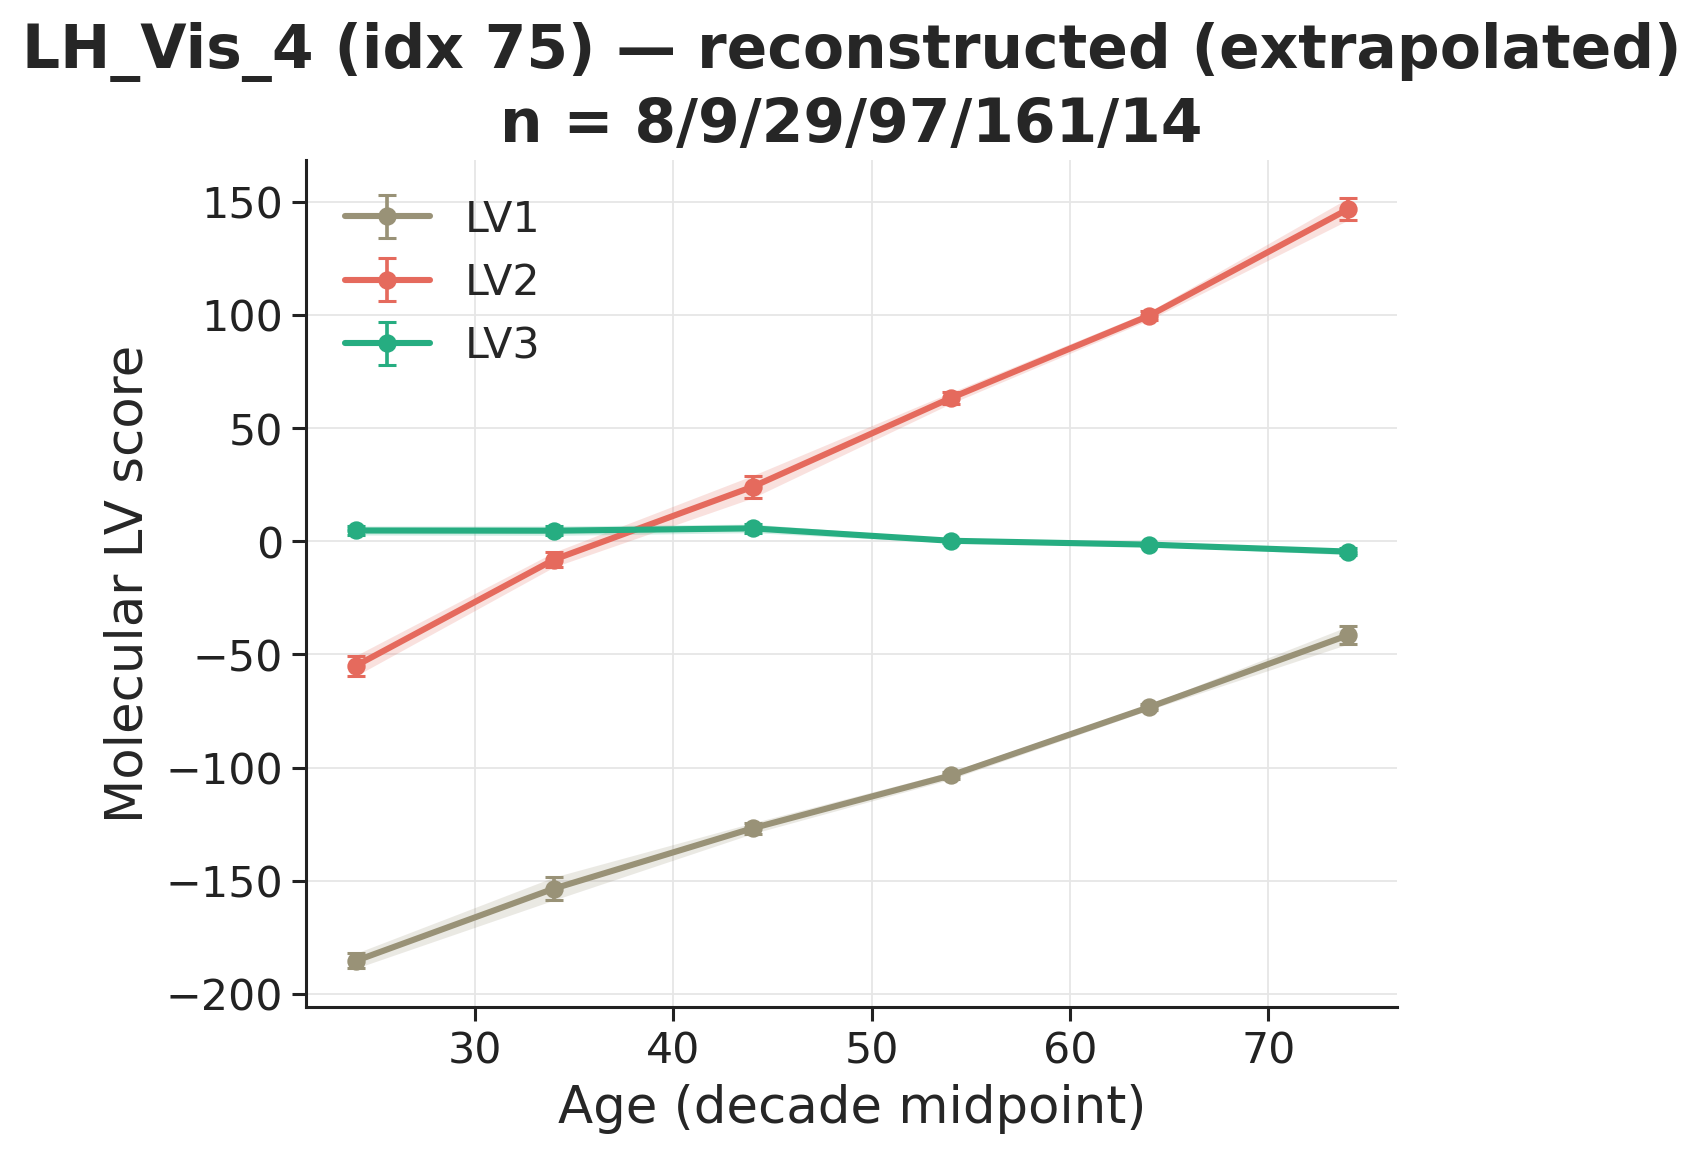

In [7]:
PARCEL       = 75 # 'LH_Default_PFC_4'   # parcel_idx int or native name; matched -> raw+truth+recon, else recon only
SHOW_SCATTER = False
FONT_SCALE   = 1.4
EXPORT_DIR   = 'out/brain_renders'  # None to skip saving

_pos, _name, _pidx = pgp.resolve_region_position(TARGET_META, REGIONS, PARCEL)
_tag = _name.replace(' ', '_').replace('/', '-')
if bool(MATCHED_MASK[_pos]):
    stages = (('raw', 'raw GTEx (non-harmonized)'), ('loro_truth', 'harmonized ground truth'),
              ('loro_fused', 'reconstructed'))
else:
    print(f'{_name} (idx {_pidx}) is extrapolated — GTEx never sampled it; reconstruction only.')
    stages = (('loro_fused', 'reconstructed (extrapolated)'),)

for stage, lab in stages:
    pgp.render_region_progression(T_BY_STAGE[stage], AGES_BY_STAGE[stage], REGIONS, TARGET_META, PARCEL,
                                  stage_label=lab, n_lv=N_COMP, show_scatter=SHOW_SCATTER,
                                  font_scale=FONT_SCALE, export_dir=EXPORT_DIR, export_tag=f'{_tag}__{stage}')